In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [3]:
df = pd.read_csv('app_users_dataset.csv')

print(df.shape)
print("=" * 70)

df[["Users", "Ad_Spend", "Ad_Spend_Lag1", "Day"]].describe()

(180, 5)


,Users,Ad_Spend,Ad_Spend_Lag1,Day
count,180.000000,180.000000,180.000000,180.000000
mean,266.883333,18.266667,18.205000,90.500000
std,83.646722,20.267871,20.306647,52.105662
min,120.000000,0.000000,0.000000,1.000000
25%,207.750000,0.000000,0.000000,45.750000
50%,257.500000,14.600000,14.600000,90.500000
75%,317.500000,33.625000,33.625000,135.250000
max,513.000000,59.900000,59.900000,180.000000



----------------------------------------------------------------------
Descriptive Statistics for Users:
----------------------------------------------------------------------
Mean: 266.88
Median: 257.50
Standard Deviation: 83.65
Skewness: 0.641
Kurtosis: -0.156

----------------------------------------------------------------------
Descriptive Statistics for Ad_Spend:
----------------------------------------------------------------------
Mean: $18.27
Median: $14.60
Standard Deviation: $20.27
Number of days without ads: 82 days
Number of days with ads: 98 days

----------------------------------------------------------------------
Comparison of Users on weekdays vs weekends:
----------------------------------------------------------------------
Average Users on weekdays: 245.95
Average Users on weekends: 321.30
Difference: 75.35 (+30.6%)

Phase 3: Correlation Analysis

----------------------------------------------------------------------
Correlation Matrix:
--------------------------

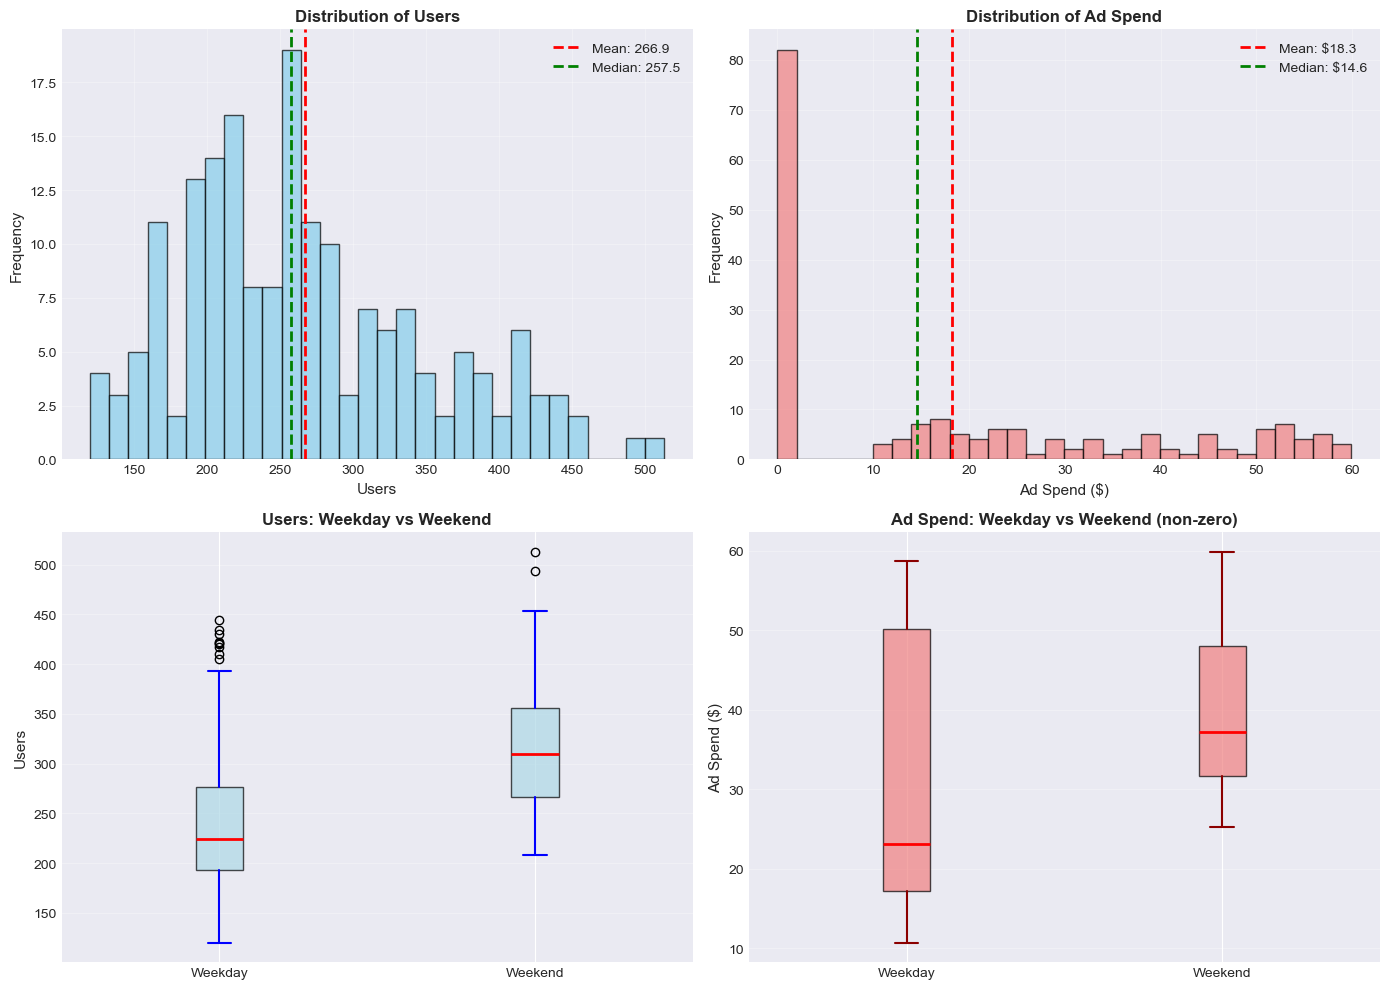

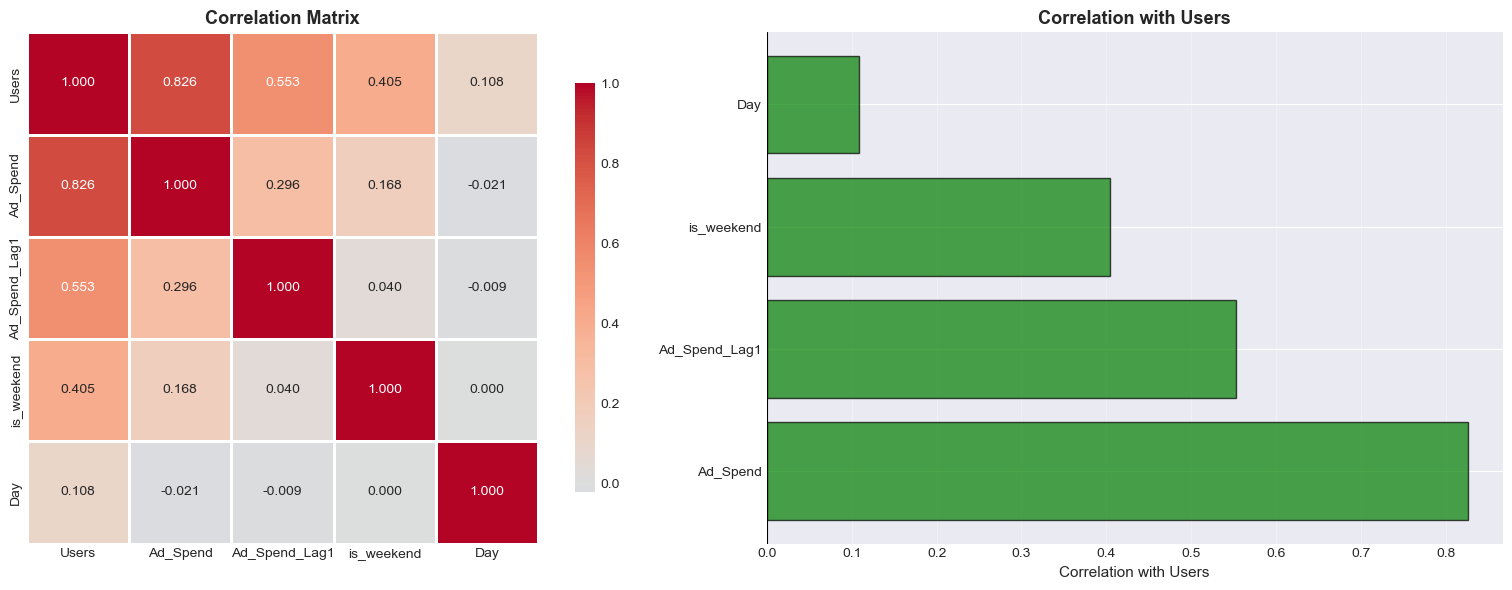

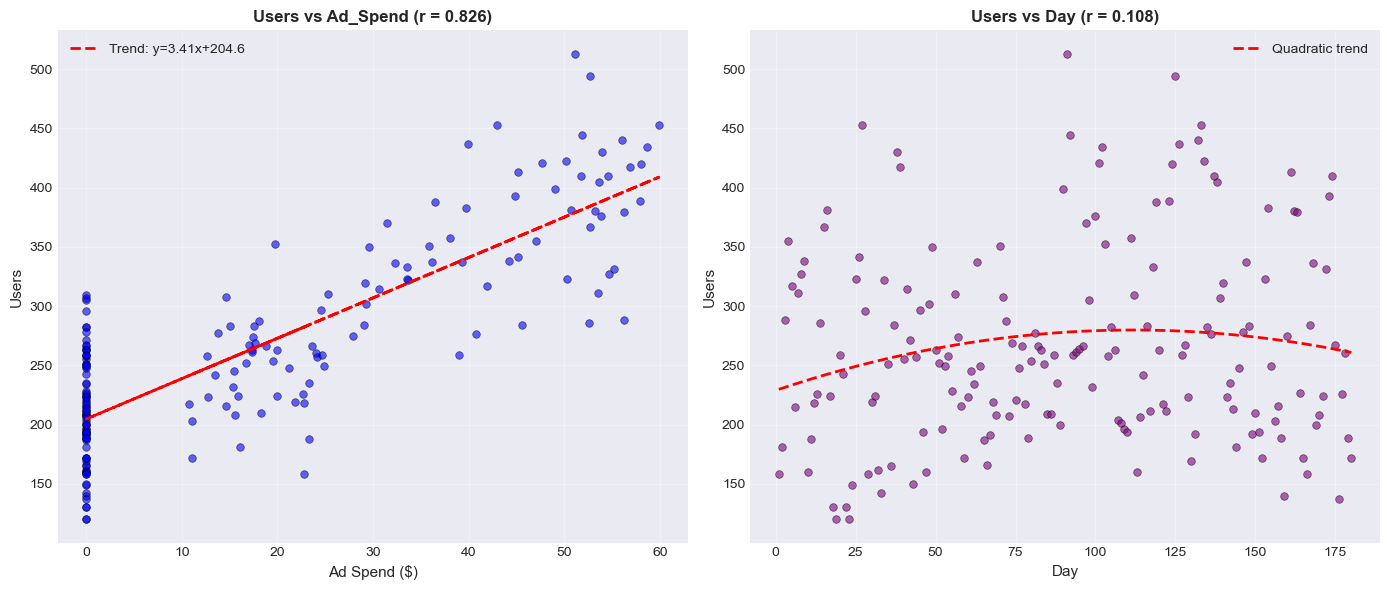

In [4]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# 2.1 Histogram and boxplot analysis for Users and Ad_Spend
# ============================================================================

# Create a 2x2 figure layout for distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot histogram for Users
axes[0, 0].hist(df['Users'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Users', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribution of Users', fontsize=12, fontweight='bold')

# Add vertical lines for mean and median of Users
axes[0, 0].axvline(df['Users'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {df["Users"].mean():.1f}')
axes[0, 0].axvline(df['Users'].median(), color='green', linestyle='--', linewidth=2,
                   label=f'Median: {df["Users"].median():.1f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot histogram for Ad_Spend
axes[0, 1].hist(df['Ad_Spend'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Ad Spend ($)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Distribution of Ad Spend', fontsize=12, fontweight='bold')

# Add vertical lines for mean and median of Ad_Spend
axes[0, 1].axvline(df['Ad_Spend'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: ${df["Ad_Spend"].mean():.1f}')
axes[0, 1].axvline(df['Ad_Spend'].median(), color='green', linestyle='--', linewidth=2,
                   label=f'Median: ${df["Ad_Spend"].median():.1f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Prepare labels and grouped data for Users boxplot by weekday/weekend
weekend_labels = ['Weekday', 'Weekend']
users_by_weekend = [
    df[df['is_weekend'] == 0]['Users'],
    df[df['is_weekend'] == 1]['Users']
]

# Plot boxplot for Users comparing weekday vs weekend
bp1 = axes[1, 0].boxplot(
    users_by_weekend,
    labels=weekend_labels,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', alpha=0.7),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='blue', linewidth=1.5),
    capprops=dict(color='blue', linewidth=1.5)
)
axes[1, 0].set_ylabel('Users', fontsize=11)
axes[1, 0].set_title('Users: Weekday vs Weekend', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Filter out zero Ad_Spend values before boxplot comparison
df_nonzero = df[df['Ad_Spend'] > 0]

# Prepare grouped Ad_Spend data for weekday/weekend comparison
adspend_by_weekend = [
    df_nonzero[df_nonzero['is_weekend'] == 0]['Ad_Spend'],
    df_nonzero[df_nonzero['is_weekend'] == 1]['Ad_Spend']
]

# Plot boxplot for Ad_Spend comparing weekday vs weekend
bp2 = axes[1, 1].boxplot(
    adspend_by_weekend,
    labels=weekend_labels,
    patch_artist=True,
    boxprops=dict(facecolor='lightcoral', alpha=0.7),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='darkred', linewidth=1.5),
    capprops=dict(color='darkred', linewidth=1.5)
)
axes[1, 1].set_ylabel('Ad Spend ($)', fontsize=11)
axes[1, 1].set_title('Ad Spend: Weekday vs Weekend (non-zero)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Adjust layout and save the Phase 2 figure
plt.tight_layout()
plt.savefig("phase2_distribution_analysis.png", dpi=300, bbox_inches='tight')
# ============================================================================
# 2.2 Statistical summary
# ============================================================================

# Print descriptive statistics for Users
print("\n" + "-" * 70)
print("Descriptive Statistics for Users:")
print("-" * 70)
print(f"Mean: {df['Users'].mean():.2f}")
print(f"Median: {df['Users'].median():.2f}")
print(f"Standard Deviation: {df['Users'].std():.2f}")
print(f"Skewness: {df['Users'].skew():.3f}")
print(f"Kurtosis: {df['Users'].kurtosis():.3f}")

# Print descriptive statistics for Ad_Spend
print("\n" + "-" * 70)
print("Descriptive Statistics for Ad_Spend:")
print("-" * 70)
print(f"Mean: ${df['Ad_Spend'].mean():.2f}")
print(f"Median: ${df['Ad_Spend'].median():.2f}")
print(f"Standard Deviation: ${df['Ad_Spend'].std():.2f}")
print(f"Number of days without ads: {(df['Ad_Spend'] == 0).sum()} days")
print(f"Number of days with ads: {(df['Ad_Spend'] > 0).sum()} days")

# Compare Users between weekdays and weekends
print("\n" + "-" * 70)
print("Comparison of Users on weekdays vs weekends:")
print("-" * 70)
weekday_users = df[df['is_weekend'] == 0]['Users']
weekend_users = df[df['is_weekend'] == 1]['Users']
print(f"Average Users on weekdays: {weekday_users.mean():.2f}")
print(f"Average Users on weekends: {weekend_users.mean():.2f}")
print(f"Difference: {weekend_users.mean() - weekday_users.mean():.2f} "
      f"(+{((weekend_users.mean() - weekday_users.mean()) / weekday_users.mean() * 100):.1f}%)")

# ============================================================================
# Phase 3: Correlation Analysis
# ============================================================================

# Print section header for Phase 3
print("\n" + "=" * 70)
print("Phase 3: Correlation Analysis")
print("=" * 70)

# Select numeric columns for correlation analysis
corr_cols = ['Users', 'Ad_Spend', 'Ad_Spend_Lag1', 'is_weekend', 'Day']
corr_matrix = df[corr_cols].corr()

# Print the correlation matrix
print("\n" + "-" * 70)
print("Correlation Matrix:")
print("-" * 70)
print(corr_matrix.round(3))

# ============================================================================
# 3.1 Correlation heatmap
# ============================================================================

# Create a figure with two panels: heatmap and bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot the full correlation matrix as a heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
    ax=axes[0]
)
axes[0].set_title('Correlation Matrix', fontsize=13, fontweight='bold')

# Extract and sort correlations with Users
corr_with_users = corr_matrix['Users'].drop('Users').sort_values(ascending=False)

# Assign colors based on positive or negative correlation
colors = ['green' if x > 0 else 'red' for x in corr_with_users]

# Plot horizontal bar chart of correlations with Users
axes[1].barh(corr_with_users.index, corr_with_users.values,
             color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Correlation with Users', fontsize=11)
axes[1].set_title('Correlation with Users', fontsize=13, fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='x')

# Adjust layout and save the heatmap figure
plt.tight_layout()
plt.savefig("phase3_correlation_heatmap.png", dpi=300, bbox_inches='tight')

# ============================================================================
# 3.2 Scatter plots
# Keep only two plots:
# 1. Users vs Ad_Spend
# 2. Users vs Day
# ============================================================================

# Create a figure with only 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --------------------------------------------------------------------------
# Plot 1: Users vs Ad_Spend
# --------------------------------------------------------------------------

# Create scatter plot for Users versus Ad_Spend
axes[0].scatter(
    df['Ad_Spend'],
    df['Users'],
    alpha=0.6,
    s=30,
    color='blue',
    edgecolors='black',
    linewidth=0.5
)
axes[0].set_xlabel('Ad Spend ($)', fontsize=11)
axes[0].set_ylabel('Users', fontsize=11)
axes[0].set_title(
    f'Users vs Ad_Spend (r = {corr_matrix.loc["Users", "Ad_Spend"]:.3f})',
    fontsize=12,
    fontweight='bold'
)
axes[0].grid(True, alpha=0.3)

# Fit and plot a linear trend line for Users vs Ad_Spend
z = np.polyfit(df['Ad_Spend'], df['Users'], 1)
p = np.poly1d(z)
axes[0].plot(
    df['Ad_Spend'],
    p(df['Ad_Spend']),
    "r--",
    linewidth=2,
    label=f'Trend: y={z[0]:.2f}x+{z[1]:.1f}'
)
axes[0].legend()

# --------------------------------------------------------------------------
# Plot 2: Users vs Day
# --------------------------------------------------------------------------

# Create scatter plot for Users versus Day
axes[1].scatter(
    df['Day'],
    df['Users'],
    alpha=0.6,
    s=30,
    color='purple',
    edgecolors='black',
    linewidth=0.5
)
axes[1].set_xlabel('Day', fontsize=11)
axes[1].set_ylabel('Users', fontsize=11)
axes[1].set_title(
    f'Users vs Day (r = {corr_matrix.loc["Users", "Day"]:.3f})',
    fontsize=12,
    fontweight='bold'
)
axes[1].grid(True, alpha=0.3)

# Fit and plot a quadratic trend line for Users vs Day
z2 = np.polyfit(df['Day'], df['Users'], 2)
p2 = np.poly1d(z2)
axes[1].plot(
    df['Day'],
    p2(df['Day']),
    "r--",
    linewidth=2,
    label='Quadratic trend'
)
axes[1].legend()

# Adjust layout and save the updated scatter plot figure
plt.tight_layout()
plt.savefig("phase3_scatter_plots.png", dpi=300, bbox_inches='tight')

# ============================================================================
# Summary insights
# ============================================================================

# Print final summary of distribution and correlation findings
print("\n" + "=" * 70)
print("Summary of Findings:")
print("=" * 70)

# Print distribution-related findings
print("\n📊 Data Distribution:")
print(f"  • The distribution of Users is approximately normal (Skewness: {df['Users'].skew():.3f})")
print(f"  • On weekends, the average number of Users is about "
      f"{((weekend_users.mean() - weekday_users.mean()) / weekday_users.mean() * 100):.1f}% higher")
print(f"  • There are {(df['Ad_Spend'] == 0).sum()} days without advertising")

# Print correlation-related findings
print("\n🔗 Correlations:")
print(f"  • Ad_Spend has a strong positive correlation with Users "
      f"(r = {corr_matrix.loc['Users', 'Ad_Spend']:.3f})")
print(f"  • Ad_Spend_Lag1 also has a positive correlation with Users "
      f"(r = {corr_matrix.loc['Users', 'Ad_Spend_Lag1']:.3f})")
print(f"  • Day has a positive correlation with Users "
      f"(r = {corr_matrix.loc['Users', 'Day']:.3f}) - upward trend")
print(f"  • is_weekend has a positive correlation with Users "
      f"(r = {corr_matrix.loc['Users', 'is_weekend']:.3f})")





📊 Section 1: Categorizing Days Based on Ad Spend
----------------------------------------------------------------------

Users statistics by ad spend category:
               Users                          Ad_Spend
               count    mean    std  min  max     mean
Ad_Category                                           
Zero              82  210.22  46.06  120  309     0.00
Low (1-25)        42  245.10  37.61  158  352    18.26
Medium (26-40)    20  334.35  41.30  259  437    33.50
High (41+)        36  383.89  59.30  276  513    51.41


Distribution of days:
  • Zero: 82 days (45.6%)
  • Low (1-25): 42 days (23.3%)
  • Medium (26-40): 20 days (11.1%)
  • High (41+): 36 days (20.0%)

----------------------------------------------------------------------
🔍 Section 2: Comparing Users on Days With/Without Advertising
----------------------------------------------------------------------

Days without advertising (Ad_Spend = 0):
  • Count: 82 days
  • Mean Users: 210.22
  • Standard De

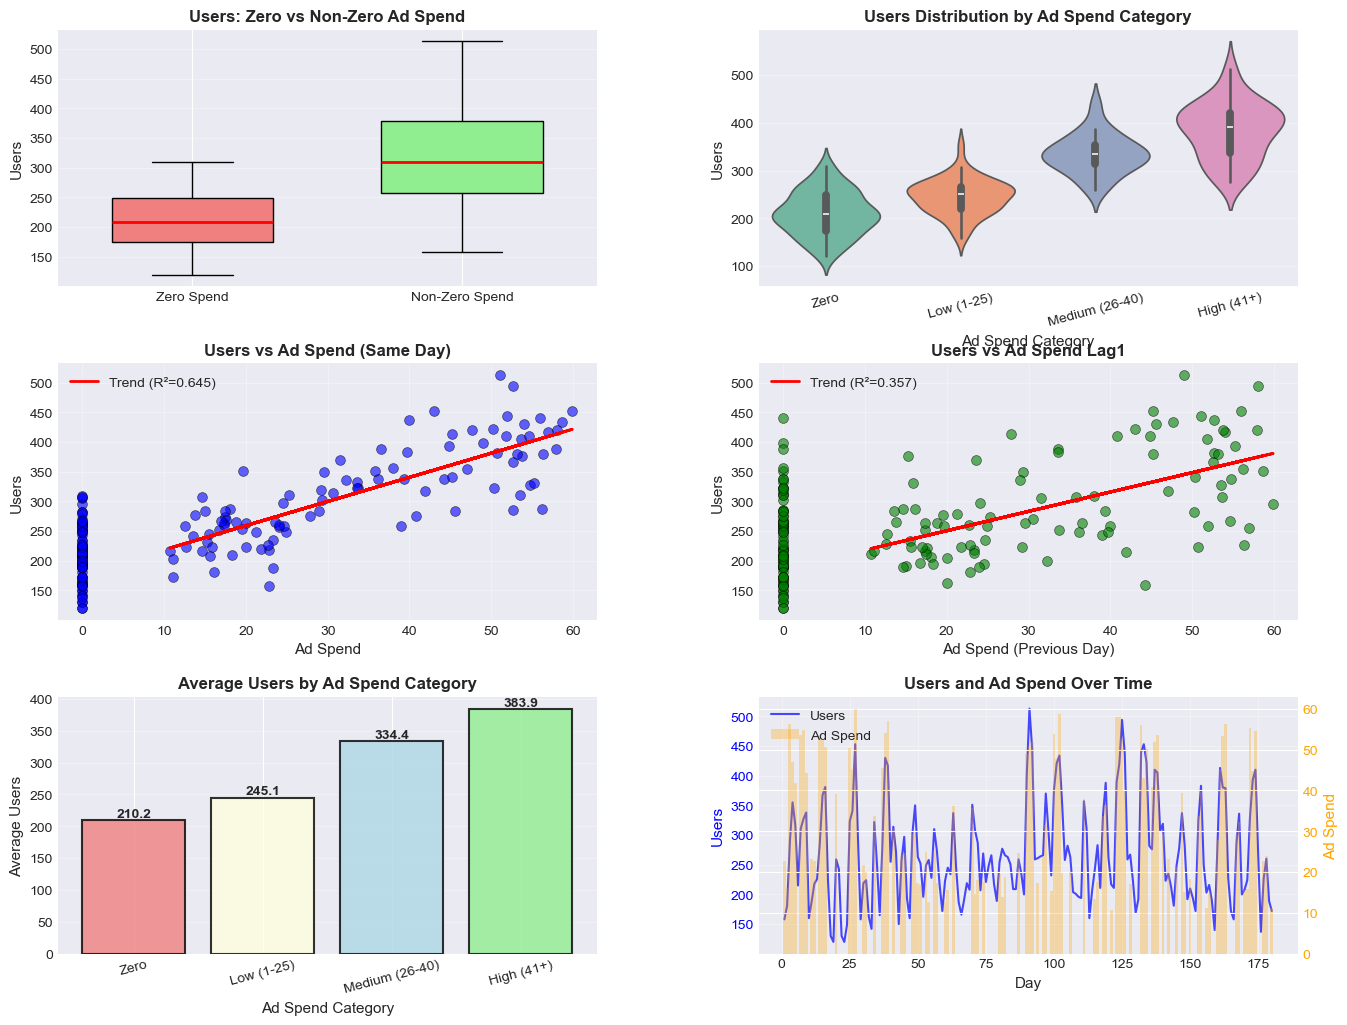

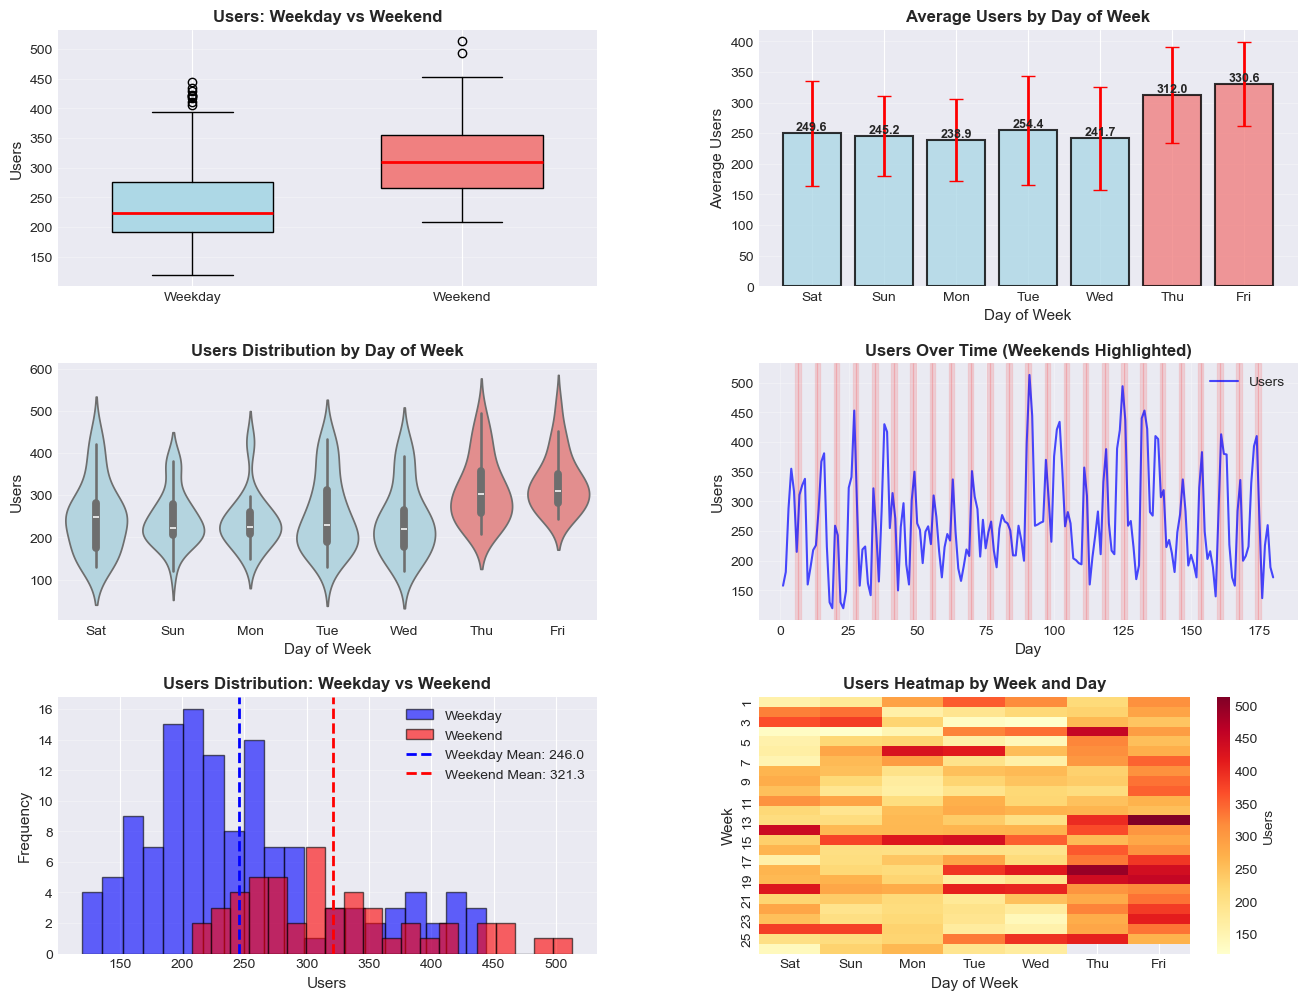

In [44]:
# Load dataset
df = pd.read_csv("app_users_dataset.csv")

# ============================================================================
# 5.1 Categorize Ad Spend Days
# ============================================================================
print("\n📊 Section 1: Categorizing Days Based on Ad Spend")
print("-" * 70)

# Create categories
df['Ad_Category'] = pd.cut(df['Ad_Spend'], 
                            bins=[-0.1, 0, 25, 40, 100],
                            labels=['Zero', 'Low (1-25)', 'Medium (26-40)', 'High (41+)'])

# Count and statistics by category
category_stats = df.groupby('Ad_Category', observed=True).agg({
    'Users': ['count', 'mean', 'std', 'min', 'max'],
    'Ad_Spend': 'mean'
}).round(2)

print("\nUsers statistics by ad spend category:")
print(category_stats)

# Calculate percentage of days in each category
category_counts = df['Ad_Category'].value_counts()
print("\n\nDistribution of days:")
for cat in ['Zero', 'Low (1-25)', 'Medium (26-40)', 'High (41+)']:
    if cat in category_counts.index:
        count = category_counts[cat]
        pct = (count / len(df)) * 100
        print(f"  • {cat}: {count} days ({pct:.1f}%)")

# ============================================================================
# 5.2 Compare Users: Zero vs Non-Zero Ad Spend
# ============================================================================
print("\n" + "-" * 70)
print("🔍 Section 2: Comparing Users on Days With/Without Advertising")
print("-" * 70)

# Split data
zero_spend = df[df['Ad_Spend'] == 0]['Users']
non_zero_spend = df[df['Ad_Spend'] > 0]['Users']

print(f"\nDays without advertising (Ad_Spend = 0):")
print(f"  • Count: {len(zero_spend)} days")
print(f"  • Mean Users: {zero_spend.mean():.2f}")
print(f"  • Standard Deviation: {zero_spend.std():.2f}")
print(f"  • Median: {zero_spend.median():.2f}")

print(f"\nDays with advertising (Ad_Spend > 0):")
print(f"  • Count: {len(non_zero_spend)} days")
print(f"  • Mean Users: {non_zero_spend.mean():.2f}")
print(f"  • Standard Deviation: {non_zero_spend.std():.2f}")
print(f"  • Median: {non_zero_spend.median():.2f}")

# Calculate difference
diff_mean = non_zero_spend.mean() - zero_spend.mean()
diff_pct = (diff_mean / zero_spend.mean()) * 100

print(f"\n📈 Difference:")
print(f"  • Mean Difference: {diff_mean:.2f} users")
print(f"  • Percentage Increase: {diff_pct:.1f}%")

# Statistical test (t-test)
t_stat, p_value = stats.ttest_ind(non_zero_spend, zero_spend)
print(f"\n🧪 t-test:")
print(f"  • t-statistic: {t_stat:.4f}")
print(f"  • p-value: {p_value:.6f}")
if p_value < 0.05:
    print(f"  ✅ The difference is statistically significant (p < 0.05)")
else:
    print(f"  ⚠️  The difference is not statistically significant (p >= 0.05)")

# ============================================================================
# 5.3 Visualize Ad Spend Impact
# ============================================================================
print("\n" + "-" * 70)
print("📈 Section 3: Visualizing the Impact of Advertising")
print("-" * 70)

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Box plot comparison
ax1 = fig.add_subplot(gs[0, 0])
box_data = [zero_spend, non_zero_spend]
bp = ax1.boxplot(box_data, labels=['Zero Spend', 'Non-Zero Spend'], 
                 patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightgreen')
for median in bp['medians']:
    median.set_color('red')
    median.set_linewidth(2)
ax1.set_ylabel('Users', fontsize=11)
ax1.set_title('Users: Zero vs Non-Zero Ad Spend', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 2. Violin plot by category
ax2 = fig.add_subplot(gs[0, 1])
category_order = ['Zero', 'Low (1-25)', 'Medium (26-40)', 'High (41+)']
sns.violinplot(data=df, x='Ad_Category', y='Users', order=category_order, ax=ax2, palette='Set2')
ax2.set_xlabel('Ad Spend Category', fontsize=11)
ax2.set_ylabel('Users', fontsize=11)
ax2.set_title('Users Distribution by Ad Spend Category', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(True, alpha=0.3, axis='y')

# 3. Scatter: Users vs Ad_Spend
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(df['Ad_Spend'], df['Users'], alpha=0.6, s=50, c='blue', edgecolors='black', linewidth=0.5)
# Add trend line
mask = df['Ad_Spend'] > 0
X = df.loc[mask, 'Ad_Spend'].values.reshape(-1, 1)
y = df.loc[mask, 'Users'].values
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
ax3.plot(df.loc[mask, 'Ad_Spend'], y_pred, color='red', linewidth=2, label=f'Trend (R²={r2_score(y, y_pred):.3f})')
ax3.set_xlabel('Ad Spend', fontsize=11)
ax3.set_ylabel('Users', fontsize=11)
ax3.set_title('Users vs Ad Spend (Same Day)', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Scatter: Users vs Ad_Spend_Lag1
ax4 = fig.add_subplot(gs[1, 1])
df['Ad_Spend_Lag1'] = df['Ad_Spend'].shift(1)
mask_lag = df['Ad_Spend_Lag1'] > 0
ax4.scatter(df['Ad_Spend_Lag1'], df['Users'], alpha=0.6, s=50, c='green', edgecolors='black', linewidth=0.5)
# Add trend line
X_lag = df.loc[mask_lag, 'Ad_Spend_Lag1'].values.reshape(-1, 1)
y_lag = df.loc[mask_lag, 'Users'].values
model_lag = LinearRegression()
model_lag.fit(X_lag, y_lag)
y_pred_lag = model_lag.predict(X_lag)
ax4.plot(df.loc[mask_lag, 'Ad_Spend_Lag1'], y_pred_lag, color='red', linewidth=2, 
         label=f'Trend (R²={r2_score(y_lag, y_pred_lag):.3f})')
ax4.set_xlabel('Ad Spend (Previous Day)', fontsize=11)
ax4.set_ylabel('Users', fontsize=11)
ax4.set_title('Users vs Ad Spend Lag1', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Bar plot: Average Users by Category
ax5 = fig.add_subplot(gs[2, 0])
avg_users = df.groupby('Ad_Category', observed=True)['Users'].mean().reindex(category_order)
colors_bar = ['lightcoral', 'lightyellow', 'lightblue', 'lightgreen']
bars = ax5.bar(category_order, avg_users, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=1.5)
# Add value labels
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax5.set_xlabel('Ad Spend Category', fontsize=11)
ax5.set_ylabel('Average Users', fontsize=11)
ax5.set_title('Average Users by Ad Spend Category', fontsize=12, fontweight='bold')
ax5.tick_params(axis='x', rotation=15)
ax5.grid(True, alpha=0.3, axis='y')

# 6. Time series with Ad Spend overlay
ax6 = fig.add_subplot(gs[2, 1])
ax6_twin = ax6.twinx()
ax6.plot(df['Day'], df['Users'], color='blue', linewidth=1.5, label='Users', alpha=0.7)
ax6_twin.bar(df['Day'], df['Ad_Spend'], color='orange', alpha=0.3, label='Ad Spend', width=1)
ax6.set_xlabel('Day', fontsize=11)
ax6.set_ylabel('Users', fontsize=11, color='blue')
ax6_twin.set_ylabel('Ad Spend', fontsize=11, color='orange')
ax6.set_title('Users and Ad Spend Over Time', fontsize=12, fontweight='bold')
ax6.tick_params(axis='y', labelcolor='blue')
ax6_twin.tick_params(axis='y', labelcolor='orange')
ax6.grid(True, alpha=0.3)
# Combine legends
lines1, labels1 = ax6.get_legend_handles_labels()
lines2, labels2 = ax6_twin.get_legend_handles_labels()
ax6.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.savefig("phase5_ad_spend_impact.png", dpi=300, bbox_inches='tight')

# ============================================================================
# 5.4 Regression Analysis: Ad Spend Effect
# ============================================================================
print("\n" + "-" * 70)
print("📐 Section 4: Regression Analysis - Ad Spend Effect")
print("-" * 70)

# Simple regression: Users ~ Ad_Spend
X_simple = df[['Ad_Spend']].values
y_simple = df['Users'].values
model_simple = LinearRegression()
model_simple.fit(X_simple, y_simple)
y_pred_simple = model_simple.predict(X_simple)
r2_simple = r2_score(y_simple, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_simple, y_pred_simple))

print(f"\nSimple Regression: Users ~ Ad_Spend")
print(f"  • Coefficient: {model_simple.coef_[0]:.4f}")
print(f"  • Intercept: {model_simple.intercept_:.2f}")
print(f"  • R²: {r2_simple:.4f}")
print(f"  • RMSE: {rmse_simple:.2f}")
print(f"\n  💡 Interpretation: Each one-unit increase in Ad_Spend adds {model_simple.coef_[0]:.2f} users")

# Multiple regression: Users ~ Ad_Spend + Ad_Spend_Lag1
df_clean = df.dropna(subset=['Ad_Spend_Lag1'])
X_multi = df_clean[['Ad_Spend', 'Ad_Spend_Lag1']].values
y_multi = df_clean['Users'].values
model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)
y_pred_multi = model_multi.predict(X_multi)
r2_multi = r2_score(y_multi, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_multi, y_pred_multi))

print(f"\nMultiple Regression: Users ~ Ad_Spend + Ad_Spend_Lag1")
print(f"  • Ad_Spend Coefficient: {model_multi.coef_[0]:.4f}")
print(f"  • Ad_Spend_Lag1 Coefficient: {model_multi.coef_[1]:.4f}")
print(f"  • Intercept: {model_multi.intercept_:.2f}")
print(f"  • R²: {r2_multi:.4f}")
print(f"  • RMSE: {rmse_multi:.2f}")
print(f"\n  💡 Interpretation:")
print(f"     - Today's advertising: +{model_multi.coef_[0]:.2f} users per unit")
print(f"     - Yesterday's advertising: +{model_multi.coef_[1]:.2f} users per unit")

# ============================================================================
# 5.5 Correlation Analysis
# ============================================================================
print("\n" + "-" * 70)
print("🔗 Section 5: Correlation Between Advertising and Users")
print("-" * 70)

corr_adspend = df['Users'].corr(df['Ad_Spend'])
corr_lag1 = df['Users'].corr(df['Ad_Spend_Lag1'])

print(f"\nPearson Correlation:")
print(f"  • Users ↔ Ad_Spend: {corr_adspend:.4f}")
print(f"  • Users ↔ Ad_Spend_Lag1: {corr_lag1:.4f}")

if corr_adspend > corr_lag1:
    print(f"\n  📌 Same-day advertising has a stronger effect")
else:
    print(f"\n  📌 Previous-day advertising has a stronger effect")

# ============================================================================
# Summary Phase 5
# ============================================================================
print("\n" + "=" * 70)
print("Summary of Phase 5: Ad Spend Impact Analysis")
print("=" * 70)

print(f"\n🎯 Key Findings:")
print(f"\n1️⃣ Comparison of Days With/Without Advertising:")
print(f"   • Days without advertising: {zero_spend.mean():.2f} users")
print(f"   • Days with advertising: {non_zero_spend.mean():.2f} users")
print(f"   • Increase: {diff_pct:.1f}% (significant with p={p_value:.6f})")

print(f"\n2️⃣ Effect of Advertising Level:")
for cat in category_order:
    if cat in avg_users.index:
        print(f"   • {cat}: {avg_users[cat]:.2f} users")

print(f"\n3️⃣ Regression Model:")
print(f"   • Today's advertising: +{model_multi.coef_[0]:.2f} users/unit")
print(f"   • Yesterday's advertising: +{model_multi.coef_[1]:.2f} users/unit")
print(f"   • Model R²: {r2_multi:.4f}")

print(f"\n4️⃣ Correlation:")
print(f"   • Ad_Spend: {corr_adspend:.4f}")
print(f"   • Ad_Spend_Lag1: {corr_lag1:.4f}")

print("\n" + "=" * 70)
print("✅ Phase 5 completed!")
print("=" * 70)

# ============================================================================
# ============================================================================
# PHASE 6: WEEKEND IMPACT ANALYSIS
# ============================================================================
# ============================================================================

print("\n\n")
print("=" * 70)
print("PHASE 6: Weekend Impact Analysis")
print("=" * 70)

# ============================================================================
# 6.1 Define Weekend (Thursday & Friday)
# ============================================================================
print("\n📅 Section 1: Defining the Weekend")
print("-" * 70)

# Day 1 is Saturday, so:
# Thursday = (Day - 1) % 7 == 5
# Friday = (Day - 1) % 7 == 6
df['DayOfWeek'] = (df['Day'] - 1) % 7
df['is_weekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

day_names = ['Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri']
df['DayName'] = df['DayOfWeek'].apply(lambda x: day_names[x])

weekend_days = df[df['is_weekend'] == 1]
weekday_days = df[df['is_weekend'] == 0]

print(f"\nWeekend definition: Thursday and Friday")
print(f"  • Number of weekend days: {len(weekend_days)} days")
print(f"  • Number of weekdays: {len(weekday_days)} days")

# ============================================================================
# 6.2 Compare Users: Weekend vs Weekday
# ============================================================================
print("\n" + "-" * 70)
print("🔍 Section 2: Comparing Users on Weekends and Weekdays")
print("-" * 70)

print(f"\nWeekdays (Saturday to Wednesday):")
print(f"  • Count: {len(weekday_days)} days")
print(f"  • Mean Users: {weekday_days['Users'].mean():.2f}")
print(f"  • Standard Deviation: {weekday_days['Users'].std():.2f}")
print(f"  • Median: {weekday_days['Users'].median():.2f}")

print(f"\nWeekend (Thursday and Friday):")
print(f"  • Count: {len(weekend_days)} days")
print(f"  • Mean Users: {weekend_days['Users'].mean():.2f}")
print(f"  • Standard Deviation: {weekend_days['Users'].std():.2f}")
print(f"  • Median: {weekend_days['Users'].median():.2f}")

# Calculate difference
diff_weekend = weekend_days['Users'].mean() - weekday_days['Users'].mean()
diff_pct_weekend = (diff_weekend / weekday_days['Users'].mean()) * 100

print(f"\n📈 Difference:")
print(f"  • Mean Difference: {diff_weekend:.2f} users")
print(f"  • Percentage Change: {diff_pct_weekend:+.1f}%")

# Statistical test
t_stat_weekend, p_value_weekend = stats.ttest_ind(weekend_days['Users'], weekday_days['Users'])
print(f"\n🧪 t-test:")
print(f"  • t-statistic: {t_stat_weekend:.4f}")
print(f"  • p-value: {p_value_weekend:.6f}")
if p_value_weekend < 0.05:
    print(f"  ✅ The difference is statistically significant (p < 0.05)")
else:
    print(f"  ⚠️  The difference is not statistically significant (p >= 0.05)")

# ============================================================================
# 6.3 Day-by-Day Analysis
# ============================================================================
print("\n" + "-" * 70)
print("📊 Section 3: Day-by-Day Analysis")
print("-" * 70)

daily_stats = df.groupby('DayName')['Users'].agg(['mean', 'std', 'count']).reindex(day_names)

print("\nAverage Users by day of week:")
for day in day_names:
    mean_val = daily_stats.loc[day, 'mean']
    std_val = daily_stats.loc[day, 'std']
    count_val = int(daily_stats.loc[day, 'count'])
    marker = "🔴" if day in ['Thu', 'Fri'] else "⚪"
    print(f"  {marker} {day}: {mean_val:.2f} ± {std_val:.2f} ({count_val} days)")

# ============================================================================
# 6.4 Visualize Weekend Impact
# ============================================================================
print("\n" + "-" * 70)
print("📈 Section 4: Visualizing Weekend Impact")
print("-" * 70)

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Box plot: Weekend vs Weekday
ax1 = fig.add_subplot(gs[0, 0])
box_data_weekend = [weekday_days['Users'], weekend_days['Users']]
bp_weekend = ax1.boxplot(box_data_weekend, labels=['Weekday', 'Weekend'], 
                         patch_artist=True, widths=0.6)
bp_weekend['boxes'][0].set_facecolor('lightblue')
bp_weekend['boxes'][1].set_facecolor('lightcoral')
for median in bp_weekend['medians']:
    median.set_color('red')
    median.set_linewidth(2)
ax1.set_ylabel('Users', fontsize=11)
ax1.set_title('Users: Weekday vs Weekend', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 2. Bar plot: Average Users by Day
ax2 = fig.add_subplot(gs[0, 1])
colors_days = ['lightblue' if day not in ['Thu', 'Fri'] else 'lightcoral' for day in day_names]
bars_days = ax2.bar(day_names, daily_stats['mean'], color=colors_days, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.errorbar(day_names, daily_stats['mean'], yerr=daily_stats['std'], 
             fmt='none', color='red', capsize=5, linewidth=2)
for bar in bars_days:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xlabel('Day of Week', fontsize=11)
ax2.set_ylabel('Average Users', fontsize=11)
ax2.set_title('Average Users by Day of Week', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Violin plot: Users by Day
ax3 = fig.add_subplot(gs[1, 0])
sns.violinplot(data=df, x='DayName', y='Users', order=day_names, ax=ax3, palette=colors_days)
ax3.set_xlabel('Day of Week', fontsize=11)
ax3.set_ylabel('Users', fontsize=11)
ax3.set_title('Users Distribution by Day of Week', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Time series with weekend highlighting
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['Day'], df['Users'], color='blue', linewidth=1.5, alpha=0.7, label='Users')
# Highlight weekends
for idx, row in df.iterrows():
    if row['is_weekend'] == 1:
        ax4.axvspan(row['Day']-0.5, row['Day']+0.5, color='red', alpha=0.1)
ax4.set_xlabel('Day', fontsize=11)
ax4.set_ylabel('Users', fontsize=11)
ax4.set_title('Users Over Time (Weekends Highlighted)', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Histogram comparison
ax5 = fig.add_subplot(gs[2, 0])
ax5.hist(weekday_days['Users'], bins=20, alpha=0.6, color='blue', edgecolor='black', label='Weekday')
ax5.hist(weekend_days['Users'], bins=20, alpha=0.6, color='red', edgecolor='black', label='Weekend')
ax5.axvline(weekday_days['Users'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Weekday Mean: {weekday_days["Users"].mean():.1f}')
ax5.axvline(weekend_days['Users'].mean(), color='red', linestyle='--', linewidth=2, label=f'Weekend Mean: {weekend_days["Users"].mean():.1f}')
ax5.set_xlabel('Users', fontsize=11)
ax5.set_ylabel('Frequency', fontsize=11)
ax5.set_title('Users Distribution: Weekday vs Weekend', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# 6. Heatmap: Users by Week and Day
ax6 = fig.add_subplot(gs[2, 1])
df['Week'] = ((df['Day'] - 1) // 7) + 1
pivot_data = df.pivot_table(values='Users', index='Week', columns='DayName', aggfunc='mean')
pivot_data = pivot_data[day_names]  # Reorder columns
sns.heatmap(pivot_data, annot=False, fmt='.0f', cmap='YlOrRd', ax=ax6, cbar_kws={'label': 'Users'})
ax6.set_xlabel('Day of Week', fontsize=11)
ax6.set_ylabel('Week', fontsize=11)
ax6.set_title('Users Heatmap by Week and Day', fontsize=12, fontweight='bold')

plt.savefig("phase6_weekend_impact.png", dpi=300, bbox_inches='tight')

# ============================================================================
# 6.5 Weekend Effect with Ad Spend Control
# ============================================================================
print("\n" + "-" * 70)
print("🎯 Section 5: Weekend Effect Controlling for Advertising")
print("-" * 70)

# Compare weekend effect for different ad spend levels
print("\nComparing weekend effect across different advertising levels:")

# Zero ad spend
zero_weekday = df[(df['Ad_Spend'] == 0) & (df['is_weekend'] == 0)]['Users'].mean()
zero_weekend = df[(df['Ad_Spend'] == 0) & (df['is_weekend'] == 1)]['Users'].mean()
print(f"\n  No advertising (Ad_Spend = 0):")
print(f"    • Weekdays: {zero_weekday:.2f}")
print(f"    • Weekend: {zero_weekend:.2f}")
print(f"    • Difference: {zero_weekend - zero_weekday:+.2f} ({((zero_weekend - zero_weekday)/zero_weekday*100):+.1f}%)")

# Low ad spend
low_weekday = df[(df['Ad_Spend'] > 0) & (df['Ad_Spend'] <= 25) & (df['is_weekend'] == 0)]['Users'].mean()
low_weekend = df[(df['Ad_Spend'] > 0) & (df['Ad_Spend'] <= 25) & (df['is_weekend'] == 1)]['Users'].mean()
print(f"\n  Low advertising (1-25):")
print(f"    • Weekdays: {low_weekday:.2f}")
print(f"    • Weekend: {low_weekend:.2f}")
print(f"    • Difference: {low_weekend - low_weekday:+.2f} ({((low_weekend - low_weekday)/low_weekday*100):+.1f}%)")
